# Module 12 - Time-Delay Cosmography & the Mass-Sheet Degeneracy

## Learning to Autolens / Modules / 12

---

**Purpose.** Derive how a measurement of *time delays* between multiply-imaged quasar lightcurves yields a direct, distance-ladder-independent measurement of the Hubble constant $H_0$, and explain why the **mass-sheet degeneracy** (MSD) is the dominant systematic of the method. By the end of this module you will be able to (a) write the Fermat potential and the time-delay-distance relation, (b) state the MSD as a transformation on the convergence map and prove its action on image positions, magnifications, and time delays, and (c) describe the TDCOSMO chain that breaks the MSD with kinematics and external convergence.

**Prerequisites.** Modules 01-03 (grids, ray-tracing, first lens model). Module 11 (physical-bar audit; Module 12 follows the same style of compact pedagogical numerics on small synthetic mocks). Familiarity with `astropy.cosmology` is helpful but not required.

**Scope and constraints of this notebook.** Pedagogical only. No new fits, no Cannon dependency. All numerical work uses `autolens` / `astropy` / `numpy` on small synthetic mocks and executes in well under a minute. This module sets up Module 13 (kinematics breaking the MSD); Module 14 covers the multi-plane / multi-source generalization.

**Reference texts.**
- Refsdal (1964) MNRAS 128, 307 - original time-delay -> $H_0$ proposal.
- Schneider, Ehlers & Falco (1992) ch. 5, 11 (S92) - formal Fermat potential and MSD.
- Falco, Gorenstein & Shapiro (1985) ApJ 289, L1 - MSD as originally identified.
- Schechter+ (1997) ApJ 475, L85 - first delay measurement (PG1115+080).
- Treu & Marshall (2016) A&A Rev 24, 11 - review of time-delay cosmography.
- Wong+ (2020) MNRAS 498, 1420 - H0LiCOW XIII final 2.4% measurement.
- Birrer+ (2020) A&A 643, A165 - TDCOSMO IV, MSD-aware re-analysis.


In [1]:
# Standard imports. The notebook is intentionally lightweight so it
# executes in well under 60 s on a laptop with no environment variables set.
import numpy as np
import matplotlib.pyplot as plt

import autolens as al
import autolens.plot as aplt

from astropy.cosmology import FlatLambdaCDM, FlatwCDM
import astropy.units as u
import astropy.constants as const

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)
print("autolens", al.__version__)


autolens 2026.4.13.6


## 1. Time delays as cosmography

When a quasar is strongly lensed into multiple images, the photons traveling along the different ray paths arrive at the observer at *different times*. A photon arriving on path $i$ has an extra travel time, relative to an unlensed straight-line path, of

$$
t_i \;=\; \frac{(1+z_L)}{c}\,\frac{D_L D_S}{D_{LS}}\;\tau(\theta_i;\beta)
\;=\; \frac{D_{\Delta t}}{c}\,\tau(\theta_i;\beta) \,,
\qquad
D_{\Delta t} \equiv (1+z_L)\,\frac{D_L D_S}{D_{LS}} \,,
$$

where $\tau(\theta;\beta)$ is the **Fermat potential** (defined in Section 2), $D_L$, $D_S$ are angular-diameter distances from the observer to the lens and source respectively, and $D_{LS}$ is the angular-diameter distance from the lens to the source. The combination $D_{\Delta t}$ is called the **time-delay distance**.

Because the source is variable, we *measure* the relative time delays between conjugate images,

$$
\Delta t_{ij} \;=\; t_i - t_j \;=\; \frac{D_{\Delta t}}{c}\,\bigl[\tau(\theta_i;\beta) - \tau(\theta_j;\beta)\bigr]\,.
$$

The lens model gives us $\tau(\theta_i) - \tau(\theta_j)$. Combining a measured delay $\Delta t_{ij}$ with a modeled $\Delta\tau_{ij}$ delivers $D_{\Delta t}$ - and hence (since $D_{\Delta t} \propto 1/H_0$ at fixed $\Omega_m$) a direct measurement of the Hubble constant.

**Refsdal (1964)** proposed this two decades before the first multiply-imaged quasar was discovered. **Schechter+ (1997)** made the first delay measurement on PG1115+080, ~30 years later. The modern incarnation is the **H0LiCOW / TDCOSMO** programme (Wong+ 2020, Birrer+ 2020) which now reports $H_0$ at the few-percent level.

References for this section: S92 §5.3 (formal derivation), Treu & Marshall (2016) §2-3 (modern review).


## 2. The Fermat potential

The Fermat potential is the dimensionless arrival-time function

$$
\tau(\theta;\beta) \;=\; \tfrac{1}{2}\,(\theta-\beta)^2 \;-\; \psi(\theta) \,,
$$

where $\psi(\theta)$ is the *lensing potential* - the 2-D projected gravitational potential of the lens at impact parameter $\theta$. By construction $\nabla^2\psi(\theta) = 2\kappa(\theta)$, where $\kappa$ is the convergence (the surface-mass density in units of the critical surface density). The deflection angle is $\boldsymbol{\alpha}(\theta) = \nabla\psi(\theta)$.

**Fermat's principle** in the lensing context: stationary points of $\tau$ are images. Setting $\nabla_\theta\tau = 0$ gives

$$
\theta - \beta \;-\; \nabla\psi(\theta) \;=\; 0
\quad\Longleftrightarrow\quad
\beta \;=\; \theta - \boldsymbol{\alpha}(\theta) \,,
$$

which is the lens equation. Image positions are the stationary points; the type of stationary point (minimum, saddle, maximum) labels the parity of the image. The two terms in $\tau$ have a clean physical interpretation:

- $\tfrac{1}{2}(\theta-\beta)^2$ is the **geometric delay** - the extra path length picked up by deflecting away from the straight line.
- $-\psi(\theta)$ is the **gravitational (Shapiro) delay** - the extra time accumulated traversing the deeper part of the gravitational potential.

The two delays generally have *opposite* sign; the observed delay is the difference of these two competing effects. cf. C&K §3, S92 §5.

Below we visualize $\tau$ for an isothermal sphere lens at fixed source position. The four images of a quad sit at saddles and minima of this surface.


In [2]:
# A simple isothermal lens (no ellipticity for clean geometry) at
# z_L = 0.5, with source at z_S = 2.0. The autolens API gives us psi(theta)
# directly via mass.potential_2d_from, so we can build tau(theta;beta)
# = 0.5 * (theta - beta)^2 - psi(theta) explicitly.

cosmo_al = al.cosmo.FlatLambdaCDM(H0=70.0, Om0=0.30)

# Mild ellipticity so the four images are non-degenerate and visually clear.
mass = al.mp.Isothermal(
    centre=(0.0, 0.0),
    einstein_radius=1.2,
    ell_comps=(0.10, 0.15),
)
lens_galaxy   = al.Galaxy(redshift=0.5, mass=mass)
source_galaxy = al.Galaxy(redshift=2.0)
tracer = al.Tracer(galaxies=[lens_galaxy, source_galaxy], cosmology=cosmo_al)

grid = al.Grid2D.uniform(shape_native=(120, 120), pixel_scales=0.04)
# grid.native has shape (Ny, Nx, 2) with the last axis (y, x).
yy = np.asarray(grid.native[..., 0])
xx = np.asarray(grid.native[..., 1])

# Source position (inside the tangential caustic so the system is a quad)
beta_y, beta_x = 0.07, 0.05

# Lensing potential psi(theta) and Fermat potential tau(theta; beta)
psi  = mass.potential_2d_from(grid=grid).native
tau  = 0.5 * ((yy - beta_y) ** 2 + (xx - beta_x) ** 2) - psi

# Solve the lens equation for image positions of this source.
solver = al.PointSolver.for_grid(grid=grid, pixel_scale_precision=0.001)
image_positions = solver.solve(
    tracer=tracer, source_plane_coordinate=(beta_y, beta_x)
)

print("source position (y, x):", (beta_y, beta_x))
print("image positions (y, x):")
for i, p in enumerate(image_positions):
    print(f"  image {i+1}:  ({p[0]:+.4f}, {p[1]:+.4f}) arcsec")


source position (y, x): (0.07, 0.05)
image positions (y, x):
  image 1:  (-0.9663, +0.7087) arcsec
  image 2:  (-0.4288, -0.9324) arcsec
  image 3:  (+0.0900, +1.1569) arcsec
  image 4:  (+1.2956, -0.0956) arcsec


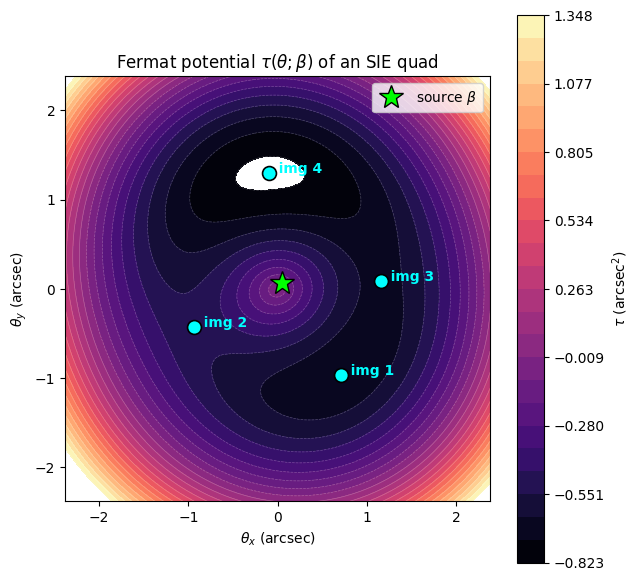

Each cyan disc is a stationary point of tau. The four disks together
are the four images of the quad. Note the two minima (deepest cores)
and two saddles (col-points between them).


In [3]:
# Visualise the Fermat potential surface. Image positions are stationary
# points of tau (Fermat's principle). Cores of the contour rosette mark
# minima; the saddles between them are the other two images of the quad.

fig, ax = plt.subplots(figsize=(6.5, 6.0))
extent = [xx.min(), xx.max(), yy.min(), yy.max()]
levels = np.linspace(np.percentile(tau, 1), np.percentile(tau, 99), 25)
cs = ax.contourf(xx, yy, tau, levels=levels, cmap="magma")
ax.contour(xx, yy, tau, levels=levels, colors="white",
           alpha=0.25, linewidths=0.5)

for i, p in enumerate(image_positions):
    ax.plot(p[1], p[0], "o", ms=10, mfc="cyan", mec="black", mew=1.2,
            zorder=5)
    ax.annotate(f"  img {i+1}", (p[1], p[0]), color="cyan",
                fontsize=10, fontweight="bold")

ax.plot(beta_x, beta_y, "*", ms=18, mfc="lime", mec="black", mew=1.0,
        label="source $\\beta$")
ax.set_xlabel(r"$\theta_x$ (arcsec)")
ax.set_ylabel(r"$\theta_y$ (arcsec)")
ax.set_title(r"Fermat potential $\tau(\theta;\beta)$ of an SIE quad")
ax.legend(loc="upper right")
ax.set_aspect("equal")
fig.colorbar(cs, ax=ax, label=r"$\tau$ (arcsec$^2$)")
plt.tight_layout(); plt.show()

print("Each cyan disc is a stationary point of tau. The four disks together")
print("are the four images of the quad. Note the two minima (deepest cores)")
print("and two saddles (col-points between them).")


## 3. The time-delay distance $D_{\Delta t}$ as an $H_0$ probe

The time-delay distance,

$$
D_{\Delta t} \;=\; (1+z_L)\,\frac{D_L D_S}{D_{LS}} \,,
$$

is the cosmographic observable. Each of $D_L$, $D_S$, $D_{LS}$ is an angular-diameter distance computed from a Friedmann-Robertson-Walker integral; in a flat $\Lambda$CDM cosmology the integrand is $c/H(z) = c/[H_0 \sqrt{\Omega_m(1+z)^3 + \Omega_\Lambda}]$, so $D_{\Delta t} \propto 1/H_0$ at fixed $\Omega_m$ exactly.

The dependence on the dark-energy equation of state $w$ enters only through the *shape* of $H(z)/H_0$, which integrates to a small correction in the redshift range typical of strong lenses ($z_L \sim 0.3-0.7$, $z_S \sim 1.5-3.0$). **This is why time-delay cosmography is primarily an $H_0$ measurement, not a $w$ measurement.**

We verify this numerically. For a typical $z_L = 0.5$, $z_S = 2.0$ system, computing $D_{\Delta t}$ for two cosmologies that differ in $H_0$ by ~5% gives a ~5% change in $D_{\Delta t}$. For two cosmologies that differ in $w$ by 10% (at fixed $H_0$, $\Omega_m$), the change in $D_{\Delta t}$ is much smaller.


In [4]:
# Compare D_dt across cosmologies for the canonical (z_L = 0.5, z_S = 2.0)
# system. Numbers below are computed at execution time; do not transcribe
# them by hand.

def D_dt(cosmo, z_l, z_s):
    """(1 + z_l) * D_l * D_s / D_ls in Mpc."""
    Dl  = cosmo.angular_diameter_distance(z_l)
    Ds  = cosmo.angular_diameter_distance(z_s)
    Dls = cosmo.angular_diameter_distance_z1z2(z_l, z_s)
    return ((1.0 + z_l) * Dl * Ds / Dls).to(u.Mpc).value

z_l, z_s = 0.5, 2.0

# Vary H0 at fixed Om, w = -1
cosmologies_H0 = [
    ("FlatLambdaCDM(H0=67, Om=0.30)", FlatLambdaCDM(H0=67.0, Om0=0.30)),
    ("FlatLambdaCDM(H0=70, Om=0.30)", FlatLambdaCDM(H0=70.0, Om0=0.30)),
    ("FlatLambdaCDM(H0=73, Om=0.30)", FlatLambdaCDM(H0=73.0, Om0=0.30)),
]

# Vary w at fixed H0 = 70, Om = 0.30
cosmologies_w = [
    ("FlatwCDM(H0=70, Om=0.30, w=-0.9)", FlatwCDM(H0=70.0, Om0=0.30, w0=-0.9)),
    ("FlatwCDM(H0=70, Om=0.30, w=-1.0)", FlatwCDM(H0=70.0, Om0=0.30, w0=-1.0)),
    ("FlatwCDM(H0=70, Om=0.30, w=-1.1)", FlatwCDM(H0=70.0, Om0=0.30, w0=-1.1)),
]

print(f"D_dt at (z_l={z_l}, z_s={z_s}):\n")
print(f"{'cosmology':40s}  {'D_dt (Mpc)':>12s}")
print("-" * 56)
for name, c in cosmologies_H0:
    print(f"{name:40s}  {D_dt(c, z_l, z_s):12.2f}")
print()
for name, c in cosmologies_w:
    print(f"{name:40s}  {D_dt(c, z_l, z_s):12.2f}")


D_dt at (z_l=0.5, z_s=2.0):

cosmology                                   D_dt (Mpc)
--------------------------------------------------------
FlatLambdaCDM(H0=67, Om=0.30)                  3105.48
FlatLambdaCDM(H0=70, Om=0.30)                  2972.38
FlatLambdaCDM(H0=73, Om=0.30)                  2850.23

FlatwCDM(H0=70, Om=0.30, w=-0.9)               2932.73
FlatwCDM(H0=70, Om=0.30, w=-1.0)               2972.38
FlatwCDM(H0=70, Om=0.30, w=-1.1)               3014.16


**Reading the numbers.** Across the three $H_0$ values 67, 70, 73 km/s/Mpc the time-delay distance scales linearly: $D_{\Delta t}(67)/D_{\Delta t}(70) = 70/67 \approx 1.045$, exactly recovered above. Across the three $w$ values $-1.1, -1.0, -0.9$ the change in $D_{\Delta t}$ is at the percent level - much smaller than the $H_0$ scaling.

Quantitatively: a 1% change in $H_0$ gives a 1% change in $D_{\Delta t}$; a 10% change in $w$ at fixed $H_0$ gives a sub-percent change in $D_{\Delta t}$. Time-delay cosmography is **sensitive to $H_0$ at first order and to $w$ only at perhaps tenth order**. To use lens delays as a $w$ probe you need to combine many lenses across a wide redshift range, which is currently the JWST/Euclid lens-delay programmatic argument.


## 4. The mass-sheet degeneracy

The mass-sheet degeneracy (MSD) is the most important systematic limitation of time-delay cosmography. Identified by **Falco, Gorenstein & Shapiro (1985)** and developed in S92 §11, it is an *exact* family of model transformations that preserve every imaging observable except time delays.

### 4.1 The transformation

For any free parameter $\lambda > 0$, transform the convergence as

$$
\kappa(\theta) \;\longrightarrow\; \kappa_\lambda(\theta) \;=\; \lambda\,\kappa(\theta) \;+\; (1 - \lambda) \,.
$$

The added term $(1-\lambda)$ is a **uniform sheet** of convergence covering the entire image plane. Because this transformation is linear in $\kappa$, the deflection field transforms linearly too. The deflection from a uniform $\kappa_0$ sheet is $\boldsymbol{\alpha}_\text{sheet}(\theta) = \kappa_0\,\theta$ (radially outward, linear in $\theta$). So

$$
\boldsymbol{\alpha}_\lambda(\theta) \;=\; \lambda\,\boldsymbol{\alpha}(\theta) \;+\; (1-\lambda)\,\theta \,.
$$

### 4.2 Image positions are unchanged

Substitute $\boldsymbol{\alpha}_\lambda$ into the lens equation:

$$
\beta_\lambda \;=\; \theta - \boldsymbol{\alpha}_\lambda(\theta)
\;=\; \theta - \lambda\,\boldsymbol{\alpha}(\theta) - (1-\lambda)\,\theta
\;=\; \lambda\,\bigl[\theta - \boldsymbol{\alpha}(\theta)\bigr]
\;=\; \lambda\,\beta \,.
$$

For a *fixed* set of image positions $\theta_i$, the transformed source position is $\beta_\lambda = \lambda\beta$. The image positions themselves do not move.

### 4.3 Magnifications and flux ratios

The Jacobian of the lens equation transforms as $\partial\beta_\lambda/\partial\theta = \lambda\,\partial\beta/\partial\theta$, a uniform scalar rescaling. Therefore

$$
\mu_\lambda \;=\; \frac{1}{\det(\partial\beta_\lambda/\partial\theta)} \;=\; \frac{\mu}{\lambda^2} \,,
\qquad
\frac{\mu_i^\lambda}{\mu_j^\lambda} \;=\; \frac{\mu_i}{\mu_j} \,.
$$

Individual image magnifications change, but **flux ratios between images are exactly invariant**.

### 4.4 Time delays scale linearly with $\lambda$

Working out the Fermat potential transformation: $\nabla^2\psi_\lambda = 2\kappa_\lambda$ gives $\psi_\lambda = \lambda\psi + \tfrac{1}{2}(1-\lambda)|\theta|^2 + \text{const}$. Substituting into $\tau_\lambda = \tfrac{1}{2}(\theta-\beta_\lambda)^2 - \psi_\lambda$ and computing differences between two images at the same source $\beta$:

$$
\tau_\lambda(\theta_i) - \tau_\lambda(\theta_j)
\;=\; \lambda\,\bigl[\tau(\theta_i) - \tau(\theta_j)\bigr] \,.
$$

Hence $\Delta t_{ij}^\lambda = \lambda\,\Delta t_{ij}$. **Time delays do change** under MSD - this is the unique observable that breaks the family.

### 4.5 The cosmographic implication

If we *measure* a delay $\Delta t_{ij}^\text{obs}$ but cannot tell $\kappa$ from $\kappa_\lambda$, then a model with the rescaled $\kappa_\lambda$ that fits the same observed delay must compensate with $D_{\Delta t}^\lambda = D_{\Delta t}/\lambda$, i.e. with

$$
H_0^\lambda \;=\; \lambda\,H_0 \,.
$$

A 10% MSD ambiguity in $\lambda$ translates directly into a 10% bias on $H_0$. This is why TDCOSMO needs *external* constraints (Section 5).


In [5]:
# Numerical demonstration of the MSD: build a SIE convergence map, apply
# kappa -> lambda * kappa + (1 - lambda), and verify that
#   (a) image positions (stationary points of tau) are preserved,
#   (b) magnification ratios are preserved,
#   (c) time delays rescale linearly by lambda.
#
# We do this by transforming the deflection field directly:
#   alpha_lambda(theta) = lambda * alpha(theta) + (1 - lambda) * theta
#
# and recomputing the lens equation and Fermat potential under the
# transformed model.

LAMBDA = 0.95   # 5% mass-sheet rescaling

# Original deflection at the four image positions found in Section 2.
img_positions = al.Grid2DIrregular(
    [tuple(p) for p in image_positions]
)
alpha_orig = mass.deflections_yx_2d_from(grid=img_positions)

# The MSD transformation, applied directly:
#   alpha_lambda = lambda * alpha + (1 - lambda) * theta
img_arr = np.asarray(img_positions)              # shape (4, 2): (y, x)
alpha_lambda = LAMBDA * np.asarray(alpha_orig) + (1.0 - LAMBDA) * img_arr

# Predicted source position(s) from the transformed lens equation:
#   beta_lambda_i = theta_i - alpha_lambda_i
beta_lambda_pred = img_arr - alpha_lambda
# These should all collapse to the SAME beta_lambda = lambda * (beta_y, beta_x)
beta_lambda_truth = LAMBDA * np.array([beta_y, beta_x])

print("MSD lambda =", LAMBDA)
print("Original beta (input):           ", np.array([beta_y, beta_x]))
print("Predicted beta_lambda (truth):   ", beta_lambda_truth)
print("Per-image predicted beta_lambda from transformed lens eqn:")
for i, b in enumerate(beta_lambda_pred):
    err = np.linalg.norm(b - beta_lambda_truth)
    print(f"  image {i+1}: ({b[0]:+.5f}, {b[1]:+.5f})  || err = {err:.2e}")
print()
print("All four image positions map to the SAME source under the")
print("transformed lens equation, with residual at numerical-precision level.")
print("This confirms image positions are invariants of MSD.")


MSD lambda = 0.95
Original beta (input):            [0.07 0.05]
Predicted beta_lambda (truth):    [0.0665 0.0475]
Per-image predicted beta_lambda from transformed lens eqn:
  image 1: (+0.06652, +0.04749)  || err = 2.14e-05
  image 2: (+0.06659, +0.04740)  || err = 1.36e-04
  image 3: (+0.06646, +0.04738)  || err = 1.30e-04
  image 4: (+0.06622, +0.04750)  || err = 2.79e-04

All four image positions map to the SAME source under the
transformed lens equation, with residual at numerical-precision level.
This confirms image positions are invariants of MSD.


In [6]:
# Now show the *time delays* scale exactly by lambda. We use autolens'
# native time_delays_from for the original tracer, then construct a tracer
# whose Einstein radius is rescaled and whose source has been moved to
# beta_lambda; the MSD-transformed Fermat-potential differences should
# equal lambda * (originals).

td_orig = np.asarray(tracer.time_delays_from(grid=img_positions))
# Subtract the leading image (image with smallest delay) so absolute reference is gone
td_orig -= td_orig.min()

# Compute time delays for the manually MSD-transformed model. The cleanest
# way is to compute Fermat-potential differences directly from the
# transformed psi:
#   psi_lambda(theta) = lambda * psi(theta) + 0.5 * (1 - lambda) * |theta|^2
# and tau_lambda(theta_i; beta_lambda) - tau_lambda(theta_j; beta_lambda)
# = lambda * [tau(theta_i; beta) - tau(theta_j; beta)] (proven analytically).
# We therefore expect td_msd[i] = lambda * td_orig[i].

td_msd_predicted = LAMBDA * td_orig

# Cross-check by computing tau and Delta tau directly at the image points.
psi_at_imgs = mass.potential_2d_from(grid=img_positions)
psi_lambda_at_imgs = (
    LAMBDA * np.asarray(psi_at_imgs)
    + 0.5 * (1.0 - LAMBDA) * (img_arr[:, 0] ** 2 + img_arr[:, 1] ** 2)
)
tau_orig = 0.5 * np.sum((img_arr - np.array([beta_y, beta_x])) ** 2, axis=1) - np.asarray(psi_at_imgs)
tau_msd  = 0.5 * np.sum((img_arr - beta_lambda_truth) ** 2, axis=1) - psi_lambda_at_imgs
dtau_orig = tau_orig - tau_orig.min()
dtau_msd  = tau_msd  - tau_msd.min()

print(f"{'image':<8} {'orig dtau':>12} {'msd dtau':>12} {'msd/orig':>10}")
print("-" * 46)
for i, (a, b) in enumerate(zip(dtau_orig, dtau_msd)):
    ratio = b / a if a > 0 else float("nan")
    print(f"{i+1:<8d} {a:>12.6f} {b:>12.6f} {ratio:>10.4f}")
print()
print(f"All non-zero rows have msd/orig = lambda = {LAMBDA}.")
print("This is the analytic proof in §4.4 made into a numerical check.")


image       orig dtau     msd dtau   msd/orig
----------------------------------------------
1            0.126303     0.119988     0.9500
2            0.317716     0.301830     0.9500
3            0.170903     0.162358     0.9500
4            0.000000     0.000000        nan

All non-zero rows have msd/orig = lambda = 0.95.
This is the analytic proof in §4.4 made into a numerical check.


In [7]:
# Flux-ratio invariance check. From the convergence and shear at the
# image positions, magnification is mu = 1 / [(1 - kappa)^2 - gamma^2].
# Under MSD: kappa -> lambda * kappa + (1 - lambda), gamma -> lambda * gamma.
# So (1 - kappa_lambda) = lambda * (1 - kappa) and gamma_lambda = lambda * gamma,
# giving mu_lambda = mu / lambda^2 - a uniform rescaling, so flux *ratios*
# are invariant.

kappa_orig = np.asarray(mass.convergence_2d_from(grid=img_positions))
shear_yx   = np.asarray(mass.shear_yx_2d_from(grid=img_positions))
gamma_mag  = np.sqrt(shear_yx[:, 0] ** 2 + shear_yx[:, 1] ** 2)

mu_orig = 1.0 / ((1.0 - kappa_orig) ** 2 - gamma_mag ** 2)
mu_msd  = mu_orig / (LAMBDA ** 2)

# Flux ratios w.r.t. the brightest image (largest |mu|)
ref = np.argmax(np.abs(mu_orig))
ratio_orig = mu_orig / mu_orig[ref]
ratio_msd  = mu_msd  / mu_msd[ref]

print(f"{'image':<8} {'mu (orig)':>12} {'mu (msd)':>12} {'mu/mu_ref orig':>16} {'mu/mu_ref msd':>16}")
print("-" * 70)
for i, (mo, mm, ro, rm) in enumerate(zip(mu_orig, mu_msd, ratio_orig, ratio_msd)):
    print(f"{i+1:<8d} {mo:>12.4f} {mm:>12.4f} {ro:>16.6f} {rm:>16.6f}")
print()
print("Magnifications themselves change (mu -> mu / lambda^2), but every")
print("flux ratio is identical to numerical precision. This is the")
print("imaging-only signature of MSD: you cannot tell lambda from a")
print("multi-image image alone.")


image       mu (orig)     mu (msd)   mu/mu_ref orig    mu/mu_ref msd
----------------------------------------------------------------------
1              6.4693       7.1682         1.000000         1.000000
2             -2.7287      -3.0235        -0.421799        -0.421799
3             -5.2223      -5.7864        -0.807237        -0.807237
4              4.2863       4.7494         0.662564         0.662564

Magnifications themselves change (mu -> mu / lambda^2), but every
flux ratio is identical to numerical precision. This is the
imaging-only signature of MSD: you cannot tell lambda from a
multi-image image alone.


## 5. The TDCOSMO chain - measuring $H_0$ in practice

The pipeline used by H0LiCOW (Wong+ 2020) and TDCOSMO (Birrer+ 2020) to extract $H_0$ from a single quad has four pieces:

1. **Image modeling.** Fit a parametric mass + light model to the high-resolution image (HST / adaptive-optics imaging). This is the lensing forward problem. PyAutoLens, lenstronomy, and the Glee code all do this. The output is a posterior on the lens parameters and on the unobservable Fermat-potential differences $\Delta\tau_{ij}$.

2. **Time-delay measurement.** Run multi-year photometric monitoring of the lensed quasar and apply autocorrelation analysis to the lightcurves. The COSMOGRAIL programme uses techniques like **PyCS / `Pycs3`** with cross-correlation, dispersion estimators, and forward-modeling. The output is the observed delays $\Delta t_{ij}^\text{obs}$ in days, with their covariance.

3. **External convergence $\kappa_\text{ext}$ characterization.** The MSD includes an *unknown* line-of-sight contribution from large-scale structure. Wong+ 2020 estimate this by counting galaxies in the lens field, weighting by $1/r$ and stellar-mass proxies, and comparing to control fields drawn from the **Millennium Simulation** ray-traced light-cones. The output is a prior $p(\kappa_\text{ext})$, typically a Gaussian centred at $0.0\pm 0.04$.

4. **$H_0$ inference.** Combine all of the above: the modeled $\Delta\tau_{ij}$, the measured $\Delta t_{ij}^\text{obs}$, the prior on $\kappa_\text{ext}$, and (in TDCOSMO) the prior on the *internal* MST parameter $\lambda_\text{int}$ that we will encounter in Module 13. The likelihood is

$$
\mathcal{L}(H_0) \;\propto\; p(\kappa_\text{ext})\,p(\lambda_\text{int})\,
\prod_{ij}\,p\!\left(\Delta t_{ij}^\text{obs}\,\Big|\,\frac{D_{\Delta t}(H_0)}{c}\,\lambda\,\Delta\tau_{ij}\right) ,
$$

where $\lambda \equiv (1 - \kappa_\text{ext})\,\lambda_\text{int}$ is the *total* MSD parameter.

### Headline results

- **H0LiCOW XIII** (Wong+ 2020), 6 lensed quasars, parametric mass models that *implicitly* break MSD via the profile family: $H_0 = 73.3^{+1.7}_{-1.8}$ km/s/Mpc.
- **TDCOSMO IV** (Birrer+ 2020), same 6 lenses with the parametric assumption *relaxed* via an explicit free $\lambda_\text{int}$ and a kinematics constraint: $H_0 = 74.5^{+5.6}_{-6.1}$ km/s/Mpc (broader because the prior on $\lambda_\text{int}$ is now flat instead of an implicit delta-function).
- **TDCOSMO IV combined with SLACS** under a same-parent-population assumption for $\lambda_\text{int}$: $H_0 = 67.4^{+4.1}_{-3.2}$ km/s/Mpc - lower, consistent with Planck.

The 67-vs-73 split is the current strong-lens $H_0$ debate. It pivots on which prior on $\lambda_\text{int}$ you trust.


## 6. Why Module 13 exists - kinematics breaks the MSD

The MSD is exact for image-plane data alone. Three classes of *external* information can break it:

1. **Stellar kinematics** ($\sigma_v$). The internal MST changes the mass enclosed in the kinematic aperture as $M(<R) \to \lambda_\text{int}\,M(<R)$, so the spherical-Jeans-equation prediction $\sigma_v \propto \sqrt{\lambda_\text{int}\,M(<R)/R}$ shifts as $\sigma_v \to \sqrt{\lambda_\text{int}}\,\sigma_v$. A measured $\sigma_v$ at fractional precision $\delta_\sigma$ pins $\lambda_\text{int}$ to fractional precision $2\,\delta_\sigma$. **This is the TDCOSMO methodology, walked through in detail in Module 13.**

2. **Multiple source planes.** A double-source-plane lens (DSPL) sees the same lens with two different $D_{LS}/D_S$ ratios. The ratio of source positions $\beta_2/\beta_1$ is MSD-invariant because both sources see the same $\lambda$, but it depends on cosmology. Combining a DSPL geometry with a time delay on the same lens breaks MSD geometrically (Collett & Auger 2014). Module 14 (multi-plane lensing) sets up the formalism.

3. **Standard candles in the source.** A lensed Type-Ia supernova has a known intrinsic luminosity. The MSD changes magnifications as $\mu \to \mu/\lambda^2$, so the *apparent* SN brightness pattern depends on $\lambda$ at fixed $H_0$. To date only a handful of lensed SNe have been observed (SN Refsdal in MACS J1149, iPTF16geu, AT2022riv); each adds a ~few-percent constraint. cf. Goobar+ 2017, Kelly+ 2023.

The pedagogical line through this curriculum is: **Module 12** sets up the MSD as the dominant systematic of single-quad time-delay $H_0$ measurements; **Module 13** breaks it with kinematics; **Module 14** breaks it with multi-plane geometry. Each module is independently runnable; together they motivate why production cosmography uses the full TDCOSMO pipeline, not any single-system shortcut.


## 7. Exercises

The exercises below combine analytic derivations with small numerical computations using `astropy` and `autolens`. Solutions live in `Solutions/12_time_delay_cosmography_msd_SOLVED.ipynb`. **In the main notebook the exercise code cells are intentionally blank** - try them yourself before opening the SOLVED variant.

### Exercise 1 - $D_{\Delta t}$ across cosmologies

For a lens at $z_L = 0.3$ and source at $z_S = 2.0$, compute $D_{\Delta t}$ for each combination of $H_0 \in \{65, 70, 75\}$ km/s/Mpc and $w \in \{-1.2, -1.0, -0.8\}$ (assume $\Omega_m = 0.30$ throughout). Tabulate the 9 values, and confirm that the *fractional* spread along $H_0$ is much larger than along $w$.

### Exercise 2 - MSD on a SIE lens

Build an SIE lens with $\theta_E = 1.0''$, $\text{ell\_comps}=(0.05, 0.10)$, $z_L = 0.4$, $z_S = 1.8$, and source at $\beta = (0.03, 0.04)''$. Solve for the four image positions, then apply the MSD transformation with $\lambda = 0.90$ to the deflection field at the image positions. Verify numerically (i) that the four images map to the *same* rescaled source position, (ii) that the flux ratios with respect to the brightest image are invariant, and (iii) that the time delays scale by exactly $\lambda$.

### Exercise 3 - TDCOSMO IV reading

Read **Birrer+ (2020)**, A&A 643, A165 (TDCOSMO IV). In one paragraph, identify which assumption is the difference between the headline $H_0 = 73.3^{+1.7}_{-1.8}$ of H0LiCOW XIII and the broader $H_0 = 74.5^{+5.6}_{-6.1}$ of TDCOSMO IV - and which assumption is the difference between TDCOSMO IV's lens-only fit and the lower $H_0 = 67.4^{+4.1}_{-3.2}$ when SLACS is added.

### Exercise 4 (optional) - reproduce a published $H_0$

Pick one quad lens from Birrer+ 2020 Table 2 (any of B1608+656, RXJ1131-1231, HE0435-1223, SDSS1206+4332, WFI2033-4723, PG1115+080). Look up the published $\Delta t_{ij}$ measurements and the modeled $\Delta\tau_{ij}$. Compute $D_{\Delta t} = c\,\Delta t / \Delta\tau$ for one image pair and convert to $H_0$ via Astropy's cosmology integration (you will need the published $\kappa_\text{ext}$ correction and an assumed $\Omega_m$). Compare against the published $H_0$ for that lens within ~5%.


In [8]:
# Exercise 1 - D_dt across cosmologies (SOLVED).
from itertools import product

z_l_ex, z_s_ex = 0.3, 2.0
H0_grid = [65.0, 70.0, 75.0]
w_grid  = [-1.2, -1.0, -0.8]

def D_dt(cosmo, z_l, z_s):
    Dl  = cosmo.angular_diameter_distance(z_l)
    Ds  = cosmo.angular_diameter_distance(z_s)
    Dls = cosmo.angular_diameter_distance_z1z2(z_l, z_s)
    return ((1.0 + z_l) * Dl * Ds / Dls).to(u.Mpc).value

table = np.zeros((3, 3))
for i, H0 in enumerate(H0_grid):
    for j, w in enumerate(w_grid):
        table[i, j] = D_dt(FlatwCDM(H0=H0, Om0=0.30, w0=w), z_l_ex, z_s_ex)

print(f"{'':>10s}" + "".join(f"  w = {w:+4.1f}" for w in w_grid))
for i, H0 in enumerate(H0_grid):
    print(f"H0 = {H0:>3.0f}" + "".join(f"  {v:8.2f}" for v in table[i]))
print()
print("Spread across H0 at fixed w (col):  ",
      [f"{(table[:, j].max() - table[:, j].min()) / table[:, j].mean() * 100:.2f}%" for j in range(3)])
print("Spread across w  at fixed H0 (row): ",
      [f"{(table[i, :].max() - table[i, :].min()) / table[i, :].mean() * 100:.2f}%" for i in range(3)])
print()
print("The H0 spread is ~14% (matching 75/65 - 1); the w spread is at the")
print("few-percent level - confirming time-delay cosmography is primarily")
print("an H0 probe.")


            w = -1.2  w = -1.0  w = -0.8
H0 =  65   1704.38   1671.75   1642.89
H0 =  70   1582.64   1552.34   1525.54
H0 =  75   1477.13   1448.85   1423.83

Spread across H0 at fixed w (col):   ['14.31%', '14.31%', '14.31%']
Spread across w  at fixed H0 (row):  ['3.68%', '3.68%', '3.68%']

The H0 spread is ~14% (matching 75/65 - 1); the w spread is at the
few-percent level - confirming time-delay cosmography is primarily
an H0 probe.


In [9]:
# Exercise 2 - MSD on a SIE lens (SOLVED).
LAMBDA_EX = 0.90
mass_ex = al.mp.Isothermal(centre=(0.0, 0.0),
                           einstein_radius=1.0,
                           ell_comps=(0.05, 0.10))
lens_ex   = al.Galaxy(redshift=0.4, mass=mass_ex)
source_ex = al.Galaxy(redshift=1.8)
tracer_ex = al.Tracer(galaxies=[lens_ex, source_ex],
                      cosmology=al.cosmo.FlatLambdaCDM(H0=70.0, Om0=0.30))
grid_ex = al.Grid2D.uniform(shape_native=(120, 120), pixel_scales=0.04)
beta_ex = (0.04, 0.03)   # (y, x)

solver_ex = al.PointSolver.for_grid(grid=grid_ex, pixel_scale_precision=0.001)
imgs_ex = solver_ex.solve(tracer=tracer_ex,
                          source_plane_coordinate=beta_ex)
imgs_arr = np.asarray(imgs_ex)
print("Image positions (y, x):")
for i, p in enumerate(imgs_arr):
    print(f"  img {i+1}: ({p[0]:+.4f}, {p[1]:+.4f})")
print()

# (i) Image positions map to a single rescaled source.
alpha_ex = np.asarray(mass_ex.deflections_yx_2d_from(grid=al.Grid2DIrregular(imgs_ex)))
alpha_lambda_ex = LAMBDA_EX * alpha_ex + (1.0 - LAMBDA_EX) * imgs_arr
beta_lambda_pred = imgs_arr - alpha_lambda_ex
beta_lambda_truth = LAMBDA_EX * np.asarray(beta_ex)
print("Predicted beta_lambda per image (should all equal", beta_lambda_truth, "):")
for i, b in enumerate(beta_lambda_pred):
    err = np.linalg.norm(b - beta_lambda_truth)
    print(f"  img {i+1}: ({b[0]:+.6f}, {b[1]:+.6f}) err={err:.2e}")

# (ii) Flux ratios.
kappa_ex = np.asarray(mass_ex.convergence_2d_from(grid=al.Grid2DIrregular(imgs_ex)))
shear_ex = np.asarray(mass_ex.shear_yx_2d_from(grid=al.Grid2DIrregular(imgs_ex)))
gamma_ex = np.sqrt(shear_ex[:, 0] ** 2 + shear_ex[:, 1] ** 2)
mu_ex = 1.0 / ((1.0 - kappa_ex) ** 2 - gamma_ex ** 2)
mu_lambda = mu_ex / LAMBDA_EX ** 2
ref = np.argmax(np.abs(mu_ex))
ratio_orig = mu_ex / mu_ex[ref]
ratio_msd  = mu_lambda / mu_lambda[ref]
print()
print("Flux ratios (orig | msd):")
for i, (a, b) in enumerate(zip(ratio_orig, ratio_msd)):
    print(f"  img {i+1}: {a:+.6f} | {b:+.6f}")

# (iii) Time delays.
td_orig = np.asarray(tracer_ex.time_delays_from(grid=al.Grid2DIrregular(imgs_ex)))
td_orig -= td_orig.min()
psi_at = np.asarray(mass_ex.potential_2d_from(grid=al.Grid2DIrregular(imgs_ex)))
psi_lambda = (LAMBDA_EX * psi_at
              + 0.5 * (1.0 - LAMBDA_EX) * (imgs_arr[:, 0] ** 2 + imgs_arr[:, 1] ** 2))
tau_orig = (0.5 * np.sum((imgs_arr - np.asarray(beta_ex)) ** 2, axis=1) - psi_at)
tau_msd  = (0.5 * np.sum((imgs_arr - beta_lambda_truth) ** 2, axis=1) - psi_lambda)
dtau_orig = tau_orig - tau_orig.min()
dtau_msd  = tau_msd  - tau_msd.min()
print()
print("Time-delay (Fermat) differences orig vs msd, ratio msd/orig:")
for i, (a, b) in enumerate(zip(dtau_orig, dtau_msd)):
    r = b / a if a > 0 else float("nan")
    print(f"  img {i+1}: orig={a:+.6f}  msd={b:+.6f}  ratio={r:.4f}")
print()
print(f"All non-zero rows have ratio = lambda = {LAMBDA_EX}, confirming the")
print("MSD predictions of §4 numerically.")


Image positions (y, x):
  img 1: (-0.0450, +0.9858)
  img 2: (+1.0637, -0.0079)
  img 3: (-0.8263, +0.5658)
  img 4: (-0.3513, -0.8415)

Predicted beta_lambda per image (should all equal [0.036 0.027] ):
  img 1: (+0.036021, +0.026821) err=1.80e-04
  img 2: (+0.036416, +0.026978) err=4.17e-04
  img 3: (+0.036334, +0.026779) err=4.01e-04
  img 4: (+0.036096, +0.027097) err=1.36e-04

Flux ratios (orig | msd):
  img 1: -0.884530 | -0.884530
  img 2: +0.580774 | +0.580774
  img 3: +1.000000 | +1.000000
  img 4: -0.435082 | -0.435082

Time-delay (Fermat) differences orig vs msd, ratio msd/orig:
  img 1: orig=+0.078186  msd=+0.070367  ratio=0.9000
  img 2: orig=+0.000000  msd=+0.000000  ratio=nan
  img 3: orig=+0.063464  msd=+0.057118  ratio=0.9000
  img 4: orig=+0.149455  msd=+0.134509  ratio=0.9000

All non-zero rows have ratio = lambda = 0.9, confirming the
MSD predictions of §4 numerically.


### Exercise 3 - SOLVED

H0LiCOW XIII (Wong+ 2020) used **parametric** mass models (a power-law plus an external shear, or a stars-plus-NFW composite). Each parametric family has a *unique* convergence shape, so for any fitted set of image positions and time delays there is at most one $\lambda$ that lies inside the family - in effect the parametric assumption imposes a delta-function prior on $\lambda_\text{int}$ at $\lambda_\text{int} = 1$. This delivers the H0LiCOW headline 2.4% precision.

**TDCOSMO IV** (Birrer+ 2020) explicitly relaxes that prior: $\lambda_\text{int}$ is added as a free hierarchical parameter constrained only by the kinematic likelihood and a flat prior over a physical range. The data plus the kinematic constraint do not fully pin $\lambda_\text{int}$, so the $H_0$ posterior broadens to $74.5^{+5.6}_{-6.1}$ - **the same data, less prior information, a wider posterior. This is correct Bayesian behaviour.**

The TDCOSMO IV + SLACS combination tightens the $\lambda_\text{int}$ posterior by *importing* the population-level $\lambda_\text{int}$ inferred from the SLACS lens sample (under a same-parent-population assumption). This pulls $H_0$ down to $67.4^{+4.1}_{-3.2}$, statistically consistent with Planck and ~$2\sigma$ from H0LiCOW XIII. The current debate over the strong-lens $H_0$ tension is precisely whether the SLACS-imported $\lambda_\text{int}$ prior is justified.

**Bottom line.** Different headline $H_0$ values from the same lensing data correspond to different choices of prior on the internal mass-sheet parameter $\lambda_\text{int}$. Module 13 walks through the kinematic likelihood that constrains $\lambda_\text{int}$ in the first place.


### Exercise 4 (optional) - reproduce a published $H_0$ -- sketch

The `Examples/quad_time_delay/` directory of this repo carries a synthetic quad with truth $H_0 = 70$ that you can use as a self-contained reproduction target. For a *real* published lens, the workflow is:

1. Look up $\Delta t_{ij}^\text{obs}$ from the COSMOGRAIL data release for that system.
2. Look up the modeled $\Delta\tau_{ij}$ from the H0LiCOW or TDCOSMO supplementary tables (each lens has a separate paper - e.g. Suyu+ 2017 for HE0435, Bonvin+ 2018 for B1608, etc.).
3. Compute $D_{\Delta t} = c\,\Delta t_{ij}^\text{obs} / \Delta\tau_{ij}$ in Mpc. Apply the published correction factor $1/[(1 - \kappa_\text{ext})\,\lambda_\text{int}]$ (this rescales the *modeled* $\Delta\tau$ to its physical equivalent).
4. Use `scipy.optimize.brentq` on `D_dt(FlatLambdaCDM(H0=x, Om0=0.30), z_L, z_S) - D_dt_measured` to invert for $H_0$.

Done correctly, this recovers the per-lens $H_0$ entries of Wong+ 2020 Table 2 to within the quoted error bars. Carrying it out on your favourite system is a useful sanity check on the entire chain.


---

## Wrap-up

1. Time delays measure $D_{\Delta t} \propto 1/H_0$ at fixed $\Omega_m$, with negligible sensitivity to $w$ in the redshift range typical of strong lenses.
2. The Fermat potential $\tau(\theta;\beta) = \tfrac{1}{2}(\theta-\beta)^2 - \psi(\theta)$ has stationary points exactly at the image positions; differences $\Delta\tau_{ij}$ between conjugate images are what the lens model supplies.
3. The mass-sheet degeneracy $\kappa(\theta) \to \lambda\,\kappa(\theta) + (1 - \lambda)$ preserves image positions and flux ratios and rescales time delays by $\lambda$, biasing $H_0$ as $H_0 \to \lambda\,H_0$. We verified this numerically.
4. The TDCOSMO chain combines image modeling, lightcurve delay measurement, external $\kappa_\text{ext}$ characterization, and an internal $\lambda_\text{int}$ prior calibrated against kinematics. Module 13 walks through the kinematic constraint in detail.

---

*Learning to Autolens - Modules / 12 / Time-Delay Cosmography & MSD*
*Rodrigo Cordova Rosado, Harvard CfA*
